In [30]:
# Cell: Install Required Libraries
import sys
!{sys.executable} -m pip install xgboost lightgbm

print("✅ Installation complete! Restart the kernel and continue.")

✅ Installation complete! Restart the kernel and continue.


'C:\Users\Mr' is not recognized as an internal or external command,
operable program or batch file.


# 🏠 Pakistan House Price Prediction

## Project Overview
This notebook aims to predict house prices in Pakistan using machine learning techniques. The dataset contains property listings from major Pakistani cities including Karachi, Lahore, Islamabad, and others.

### Objectives:
- Explore and understand the Pakistani real estate market
- Preprocess and clean the data (handle missing values, convert area units)
- Perform Exploratory Data Analysis (EDA) to identify trends
- Train multiple regression models
- Evaluate and compare model performance
- Identify key features affecting house prices in Pakistan

### Dataset Source:
The dataset is from Kaggle containing Pakistani property listings with features like location, property type, area, bedrooms, bathrooms, and price.

In [2]:
# Cell 1: Import Required Libraries
# These libraries are essential for data manipulation, visualization, and machine learning

import pandas as pd          # For data manipulation and analysis
import numpy as np           # For numerical computations
import matplotlib.pyplot as plt  # For creating visualizations
import seaborn as sns        # For enhanced visualizations
import warnings              # To ignore warning messages
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [4]:
# Cell 1: Extract and Load Dataset from Downloads
import os
import zipfile
import pandas as pd

# Get your username
username = os.getlogin()

# Path to Downloads folder
downloads_path = f'C:\\Users\\{username}\\Downloads'

print("📁 Checking Downloads folder...")

# Find all zip files in Downloads
zip_files = [f for f in os.listdir(downloads_path) if f.endswith('.zip')]

if zip_files:
    print(f"\n✅ Found zip files in Downloads:")
    for i, file in enumerate(zip_files):
        print(f"{i+1}. {file}")
    
    # Use the most recent zip file (usually the first one)
    latest_zip = zip_files[0]
    zip_path = os.path.join(downloads_path, latest_zip)
    
    print(f"\n📦 Processing: {latest_zip}")
    
    # Extract to current directory
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('.')
        print("✅ Extracted successfully!")
        
        # Show extracted files
        extracted_files = zip_ref.namelist()
        print("\n📂 Extracted files:")
        for file in extracted_files:
            print(f"   - {file}")
    
    # Find the CSV file in extracted files
    csv_files = [f for f in extracted_files if f.endswith('.csv')]
    
    if csv_files:
        # Load the first CSV file
        csv_filename = csv_files[0]
        df = pd.read_csv(csv_filename)
        
        print(f"\n✅ Loaded dataset: {csv_filename}")
        print(f"📊 Dataset shape: {df.shape}")
        print(f"📝 First few rows:")
        df.head()
    else:
        print("❌ No CSV file found in the zip!")
        
else:
    print("❌ No zip files found in Downloads!")
    print("Please download the dataset from Kaggle first.")

📁 Checking Downloads folder...

✅ Found zip files in Downloads:
1. archive_3.zip

📦 Processing: archive_3.zip
✅ Extracted successfully!

📂 Extracted files:
   - Entities.csv

✅ Loaded dataset: Entities.csv
📊 Dataset shape: (168446, 18)
📝 First few rows:


## 🔍 Step 3: Initial Data Exploration
Now that we have loaded the Pakistani property dataset, let's explore its structure and understand what information it contains.

In [6]:
# Cell 3: Display First Few Rows
# This helps us understand what the data looks like

print("📝 First 5 rows of the dataset:")
df.head()

📝 First 5 rows of the dataset:


,Unnamed: 0,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,agency,agent,Total_Area
0,0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,2/4/2019,NaN,NaN,1089.004
1,1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,5/4/2019,NaN,NaN,15246.056
2,2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,7/17/2019,NaN,NaN,2178.008
3,3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,4/5/2019,NaN,NaN,10890.000
4,4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,7/10/2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,2178.008


## 📋 Step 4: Dataset Information
Let's check the column names, data types, and see if there are any missing values that need handling.

In [7]:
# Cell 4: Dataset Info and Missing Values

print("="*50)
print("📋 COLUMN INFORMATION")
print("="*50)
print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\n" + "="*50)
print("📊 DATA TYPES")
print("="*50)
print(df.dtypes)

print("\n" + "="*50)
print("🔍 MISSING VALUES CHECK")
print("="*50)
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Values'] > 0].sort_values('Missing Values', ascending=False))

📋 COLUMN INFORMATION

Column Names:
1. Unnamed: 0
2. property_id
3. location_id
4. page_url
5. property_type
6. price
7. location
8. city
9. province_name
10. latitude
11. longitude
12. baths
13. purpose
14. bedrooms
15. date_added
16. agency
17. agent
18. Total_Area

📊 DATA TYPES
Unnamed: 0         int64
property_id        int64
location_id        int64
page_url          object
property_type     object
price              int64
location          object
city              object
province_name     object
latitude         float64
longitude        float64
baths              int64
purpose           object
bedrooms           int64
date_added        object
agency            object
agent             object
Total_Area       float64
dtype: object

🔍 MISSING VALUES CHECK
        Missing Values  Percentage
agent            44072   26.163874
agency           44071   26.163281


## 📊 Step 5: Statistical Summary
Let's look at the statistical summary of numerical features to understand their ranges and distributions.

In [8]:
# Cell 5: Statistical Summary

print("="*50)
print("📊 STATISTICAL SUMMARY - NUMERICAL FEATURES")
print("="*50)
print("\nNumerical Features Summary:")
df.describe()

📊 STATISTICAL SUMMARY - NUMERICAL FEATURES

Numerical Features Summary:


,Unnamed: 0,property_id,location_id,price,latitude,longitude,baths,bedrooms,Total_Area
count,168446.000000,1.684460e+05,168446.000000,1.684460e+05,168446.000000,168446.000000,168446.000000,168446.000000,1.684460e+05
mean,84222.500000,1.559626e+07,4375.936395,1.776576e+07,29.859519,71.239804,2.874227,3.179422,1.394239e+04
std,48626.316059,2.251207e+06,3776.561581,3.531003e+07,3.807870,3.133042,2.463400,1.971401,8.623647e+05
min,0.000000,8.657500e+04,1.000000,0.000000e+00,11.052446,25.906027,0.000000,0.000000,0.000000e+00
25%,42111.250000,1.488320e+07,1058.000000,1.750000e+05,24.948536,67.130363,0.000000,2.000000,1.905757e+03
50%,84222.500000,1.665851e+07,3286.000000,8.500000e+06,31.459784,73.056182,3.000000,3.000000,4.356016e+03
75%,126333.750000,1.708662e+07,7220.000000,1.950000e+07,33.560887,73.259870,4.000000,4.000000,1.197904e+04
max,168445.000000,1.735772e+07,14220.000000,2.000000e+09,73.184088,80.161430,403.000000,68.000000,3.387988e+08


## 🏙️ Step 6: Pakistani Cities Analysis
Let's analyze the cities in our dataset to understand geographic distribution.

🏙️ CITY ANALYSIS

📍 Total unique cities: 5

📊 Top 15 cities by number of listings:
city
Karachi       60484
Lahore        41427
Islamabad     37426
Rawalpindi    20976
Faisalabad     8133
Name: count, dtype: int64


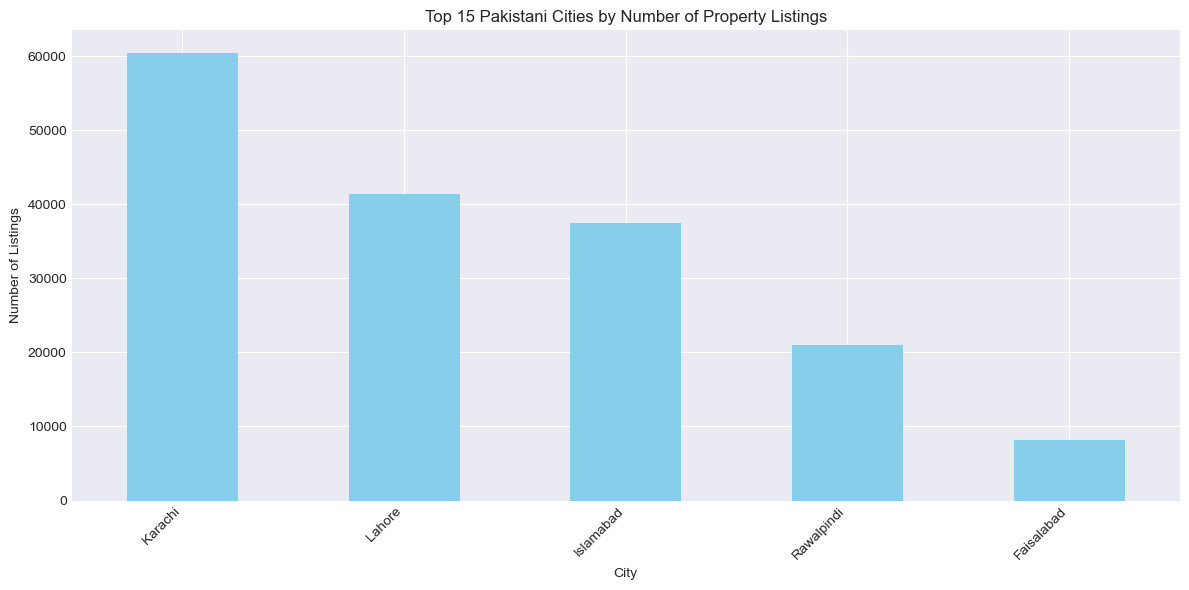


🔍 Sample of cities:
['Islamabad' 'Lahore' 'Faisalabad' 'Rawalpindi' 'Karachi']

🏞️ PROVINCE ANALYSIS

Properties by Province:
province_name
Punjab               70536
Sindh                60484
Islamabad Capital    37426
Name: count, dtype: int64


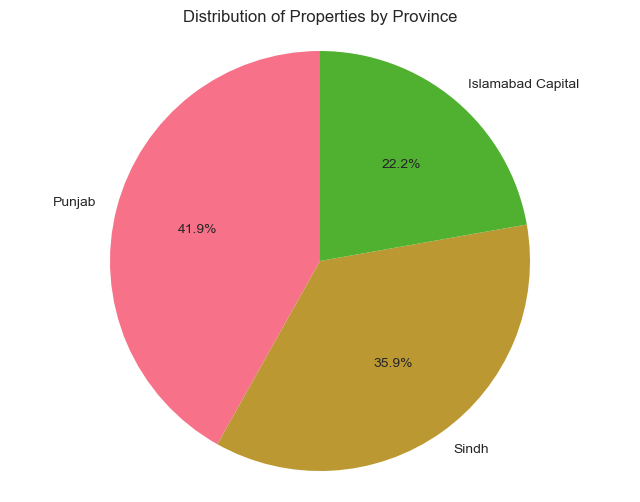

In [9]:
# Cell 6: City Analysis

print("="*50)
print("🏙️ CITY ANALYSIS")
print("="*50)

# City column is 'city'
print(f"\n📍 Total unique cities: {df['city'].nunique()}")
print("\n📊 Top 15 cities by number of listings:")
city_counts = df['city'].value_counts().head(15)
print(city_counts)

# Visualize top cities
plt.figure(figsize=(12, 6))
city_counts.plot(kind='bar', color='skyblue')
plt.title('Top 15 Pakistani Cities by Number of Property Listings')
plt.xlabel('City')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n🔍 Sample of cities:")
print(df['city'].unique()[:20])

# Province analysis
print("\n" + "="*50)
print("🏞️ PROVINCE ANALYSIS")
print("="*50)
print("\nProperties by Province:")
province_counts = df['province_name'].value_counts()
print(province_counts)

# Visualize provinces
plt.figure(figsize=(8, 6))
plt.pie(province_counts.values, labels=province_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Properties by Province')
plt.axis('equal')
plt.show()

## 🏠 Step 7: Property Types Analysis
Understanding the types of properties in our dataset.

🏠 PROPERTY TYPE ANALYSIS

📊 Unique property types: 7

Distribution of property types:
property_type
House            105468
Flat              38238
Upper Portion     13774
Lower Portion      9229
Room                685
Farm House          657
Penthouse           395
Name: count, dtype: int64


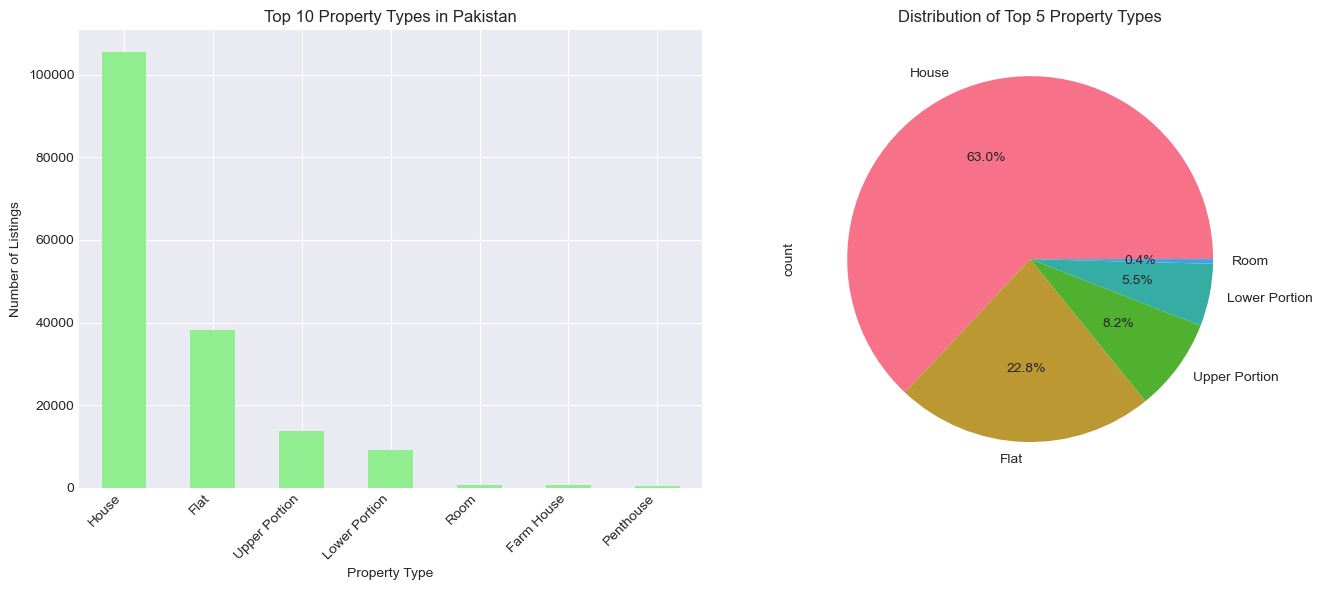


🎯 PURPOSE ANALYSIS

Properties by Purpose:
purpose
For Sale    120655
For Rent     47791
Name: count, dtype: int64


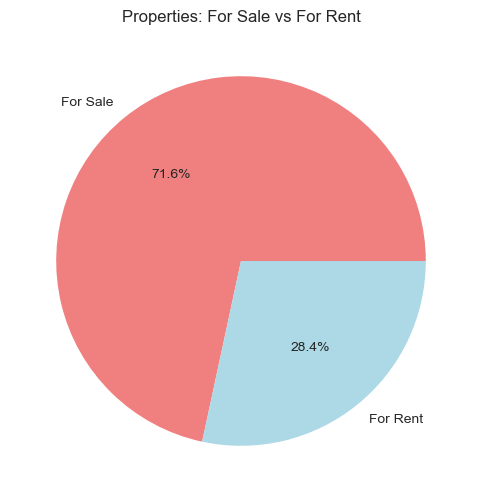

In [10]:
# Cell 7: Property Type Analysis

print("="*50)
print("🏠 PROPERTY TYPE ANALYSIS")
print("="*50)

print(f"\n📊 Unique property types: {df['property_type'].nunique()}")
print("\nDistribution of property types:")
type_counts = df['property_type'].value_counts()
print(type_counts)

# Visualize property types
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
type_counts.head(10).plot(kind='bar', color='lightgreen')
plt.title('Top 10 Property Types in Pakistan')
plt.xlabel('Property Type')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
type_counts.head(5).plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Top 5 Property Types')

plt.tight_layout()
plt.show()

# Purpose analysis (For Sale vs For Rent)
print("\n" + "="*50)
print("🎯 PURPOSE ANALYSIS")
print("="*50)
print("\nProperties by Purpose:")
purpose_counts = df['purpose'].value_counts()
print(purpose_counts)

# Visualize purpose
plt.figure(figsize=(6, 6))
plt.pie(purpose_counts.values, labels=purpose_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue'])
plt.title('Properties: For Sale vs For Rent')
plt.show()

## 📐 Step 8: Area Analysis
Since this is Pakistani data, we need to understand the area measurements.

📐 AREA ANALYSIS

Area column: Total_Area

Area statistics:
Minimum: 0.00
Maximum: 338798790.00
Mean: 13942.39
Median: 4356.02

✅ Area values are large, likely already in square feet.


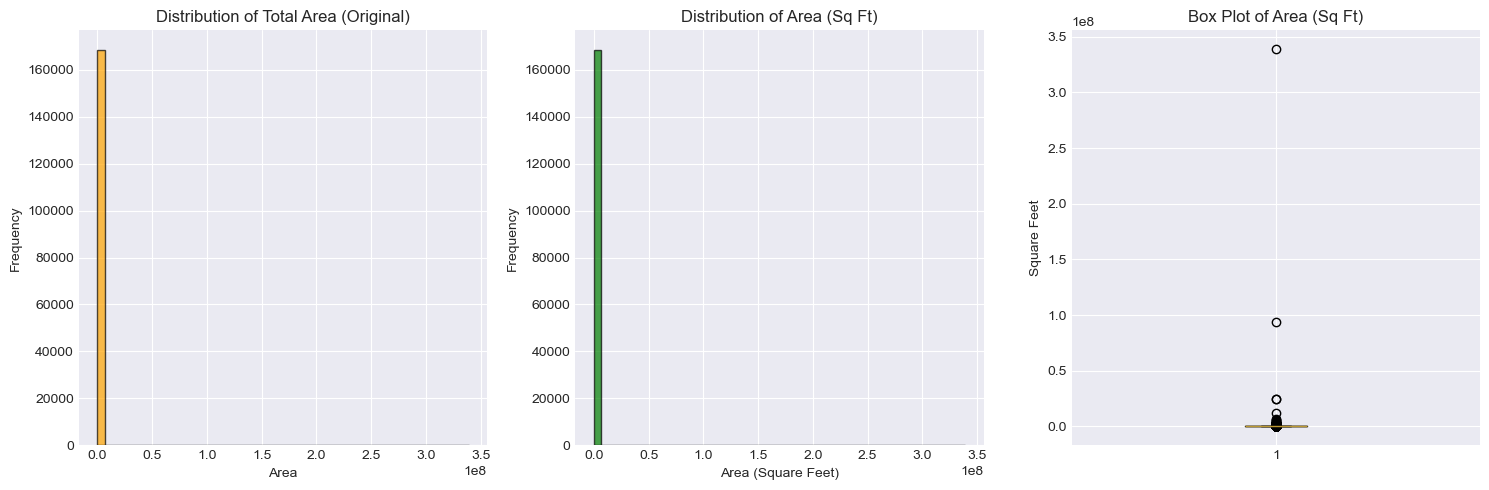

In [11]:
# Cell 8: Area Analysis

print("="*50)
print("📐 AREA ANALYSIS")
print("="*50)

print(f"\nArea column: Total_Area")
print(f"\nArea statistics:")
print(f"Minimum: {df['Total_Area'].min():.2f}")
print(f"Maximum: {df['Total_Area'].max():.2f}")
print(f"Mean: {df['Total_Area'].mean():.2f}")
print(f"Median: {df['Total_Area'].median():.2f}")

# Determine if area is in Marla or sq ft
if df['Total_Area'].max() < 200:
    print("\n⚠️  Area values are relatively small (under 200).")
    print("   This suggests area might be in Marla units.")
    print("   Conversion: 1 Marla = 272.25 sq ft")
    print("   Creating new feature: area_sqft = Total_Area * 272.25")
    
    # Create sq ft column
    df['area_sqft'] = df['Total_Area'] * 272.25
    print("✅ Created 'area_sqft' column")
else:
    print("\n✅ Area values are large, likely already in square feet.")
    df['area_sqft'] = df['Total_Area']

# Visualize area distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df['Total_Area'], bins=50, edgecolor='black', alpha=0.7, color='orange')
plt.title('Distribution of Total Area (Original)')
plt.xlabel('Area')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(df['area_sqft'], bins=50, edgecolor='black', alpha=0.7, color='green')
plt.title('Distribution of Area (Sq Ft)')
plt.xlabel('Area (Square Feet)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.boxplot(df['area_sqft'])
plt.title('Box Plot of Area (Sq Ft)')
plt.ylabel('Square Feet')

plt.tight_layout()
plt.show()

## 💰 Step 9: Price Distribution Analysis
Understanding the target variable - property prices in Pakistan.

💰 PRICE ANALYSIS

Price column: price

Price statistics (PKR):
Minimum: 0 PKR
Maximum: 2,000,000,000 PKR
Mean: 17,765,760 PKR
Median: 8,500,000 PKR
Standard Deviation: 35,310,032 PKR

📊 Outliers:
   Number of price outliers: 13547 (8.04%)


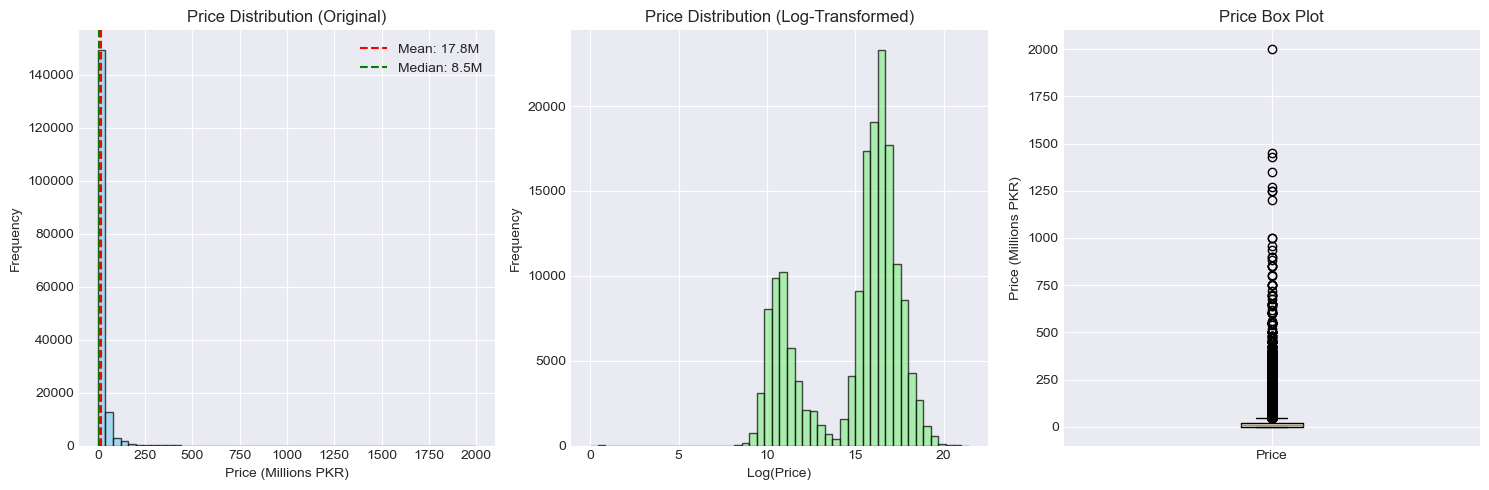


📊 AVERAGE PRICE BY PROPERTY TYPE
property_type
Farm House       59.34 Million PKR
House            24.55 Million PKR
Penthouse        16.83 Million PKR
Flat              8.25 Million PKR
Upper Portion     2.12 Million PKR
Lower Portion     1.35 Million PKR
Room              0.45 Million PKR
Name: price, dtype: object


In [12]:
# Cell 9: Price Distribution Analysis

print("="*50)
print("💰 PRICE ANALYSIS")
print("="*50)

print(f"\nPrice column: price")
print(f"\nPrice statistics (PKR):")
print(f"Minimum: {df['price'].min():,.0f} PKR")
print(f"Maximum: {df['price'].max():,.0f} PKR")
print(f"Mean: {df['price'].mean():,.0f} PKR")
print(f"Median: {df['price'].median():,.0f} PKR")
print(f"Standard Deviation: {df['price'].std():,.0f} PKR")

# Check for outliers
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"\n📊 Outliers:")
print(f"   Number of price outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# Visualize price distribution
plt.figure(figsize=(15, 5))

# Original price
plt.subplot(1, 3, 1)
plt.hist(df['price']/1e6, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Price Distribution (Original)')
plt.xlabel('Price (Millions PKR)')
plt.ylabel('Frequency')
plt.axvline(df['price'].mean()/1e6, color='red', linestyle='--', label=f'Mean: {df["price"].mean()/1e6:.1f}M')
plt.axvline(df['price'].median()/1e6, color='green', linestyle='--', label=f'Median: {df["price"].median()/1e6:.1f}M')
plt.legend()

# Log-transformed price
plt.subplot(1, 3, 2)
plt.hist(np.log1p(df['price']), bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
plt.title('Price Distribution (Log-Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

# Box plot
plt.subplot(1, 3, 3)
plt.boxplot(df['price']/1e6)
plt.title('Price Box Plot')
plt.ylabel('Price (Millions PKR)')
plt.xticks([1], ['Price'])

plt.tight_layout()
plt.show()

# Price by property type
print("\n" + "="*50)
print("📊 AVERAGE PRICE BY PROPERTY TYPE")
print("="*50)
avg_price_by_type = df.groupby('property_type')['price'].mean().sort_values(ascending=False).head(10)
print(avg_price_by_type.apply(lambda x: f'{x/1e6:.2f} Million PKR'))

## 🏙️ Step 10: Price Analysis by City
Let's see which cities have the most expensive properties.

🏙️ AVERAGE PRICE BY CITY

Top 10 Most Expensive Cities:
                    mean    count
city                             
Lahore      2.528863e+07  41427.0
Karachi     1.983883e+07  60484.0
Islamabad   1.339833e+07  37426.0
Rawalpindi  8.576443e+06  20976.0
Faisalabad  7.827574e+06   8133.0


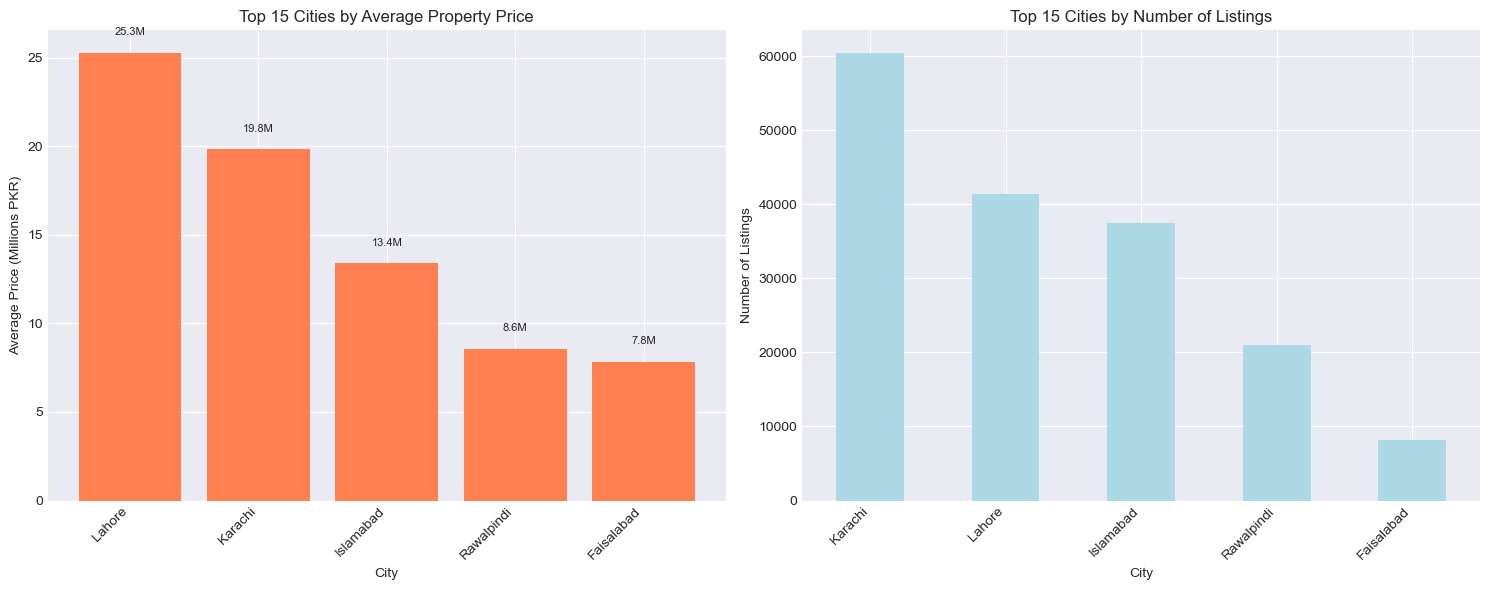

In [13]:
# Cell 10: Price by City Analysis

print("="*50)
print("🏙️ AVERAGE PRICE BY CITY")
print("="*50)

# Calculate average price by city (only cities with at least 10 properties)
city_stats = df.groupby('city')['price'].agg(['mean', 'count', 'median']).sort_values('mean', ascending=False)
city_stats_filtered = city_stats[city_stats['count'] >= 10]

print("\nTop 10 Most Expensive Cities:")
print(city_stats_filtered.head(10)[['mean', 'count']].apply(lambda x: f"{x['mean']/1e6:.2f}M PKR ({int(x['count'])} properties)" if x.name == 'mean' else x, axis=1))

# Visualize
plt.figure(figsize=(15, 6))

# Average prices
plt.subplot(1, 2, 1)
top_cities_price = city_stats_filtered.head(15)
bars = plt.bar(range(len(top_cities_price)), top_cities_price['mean']/1e6, color='coral')
plt.xticks(range(len(top_cities_price)), top_cities_price.index, rotation=45, ha='right')
plt.title('Top 15 Cities by Average Property Price')
plt.xlabel('City')
plt.ylabel('Average Price (Millions PKR)')

# Add value labels
for i, (city, row) in enumerate(top_cities_price.iterrows()):
    plt.text(i, row['mean']/1e6 + 1, f'{row["mean"]/1e6:.1f}M', ha='center', fontsize=8)

# Number of properties
plt.subplot(1, 2, 2)
top_cities_count = df['city'].value_counts().head(15)
top_cities_count.plot(kind='bar', color='lightblue')
plt.title('Top 15 Cities by Number of Listings')
plt.xlabel('City')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 🛏️ Step 11: Bedrooms Analysis
Analyzing how number of bedrooms affects property prices.

🛏️ BEDROOMS ANALYSIS

Bedrooms statistics:
count    168446.000000
mean          3.179422
std           1.971401
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          68.000000
Name: bedrooms, dtype: float64


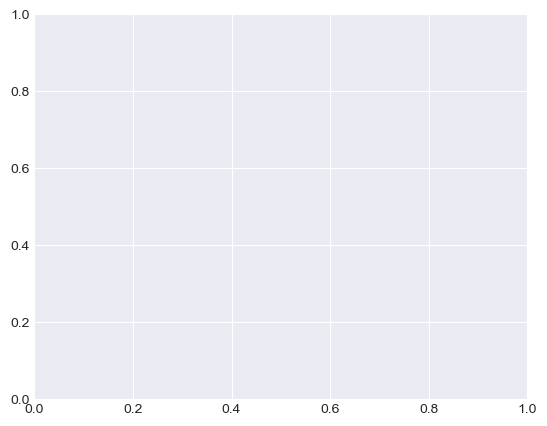

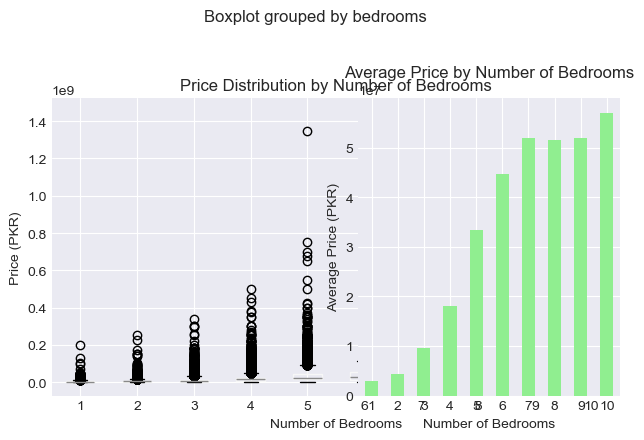


📈 Average Price by Bedrooms:
   1 bedroom(s): 2.86 Million PKR
   2 bedroom(s): 4.35 Million PKR
   3 bedroom(s): 9.50 Million PKR
   4 bedroom(s): 18.13 Million PKR
   5 bedroom(s): 33.46 Million PKR
   6 bedroom(s): 44.75 Million PKR
   7 bedroom(s): 51.92 Million PKR
   8 bedroom(s): 51.53 Million PKR
   9 bedroom(s): 51.97 Million PKR
   10 bedroom(s): 57.06 Million PKR


In [14]:
# Cell 11: Bedrooms Analysis

print("="*50)
print("🛏️ BEDROOMS ANALYSIS")
print("="*50)

print(f"\nBedrooms statistics:")
print(df['bedrooms'].describe())

# Filter to reasonable bedroom counts (1-10)
df_bedrooms = df[df['bedrooms'].between(1, 10)]

plt.figure(figsize=(14, 5))

# Box plot
plt.subplot(1, 2, 1)
df_bedrooms.boxplot(column='price', by='bedrooms')
plt.title('Price Distribution by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price (PKR)')
plt.xticks(rotation=0)

# Average price by bedrooms
plt.subplot(1, 2, 2)
bed_avg = df_bedrooms.groupby('bedrooms')['price'].mean()
bed_avg.plot(kind='bar', color='lightgreen')
plt.title('Average Price by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Average Price (PKR)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print("\n📈 Average Price by Bedrooms:")
for beds, price in bed_avg.items():
    print(f"   {beds} bedroom(s): {price/1e6:.2f} Million PKR")

## 🚿 Step 12: Bathrooms Analysis
Analyzing how number of bathrooms affects property prices.

🚿 BATHROOMS ANALYSIS

Bathrooms statistics:
count    168446.000000
mean          2.874227
std           2.463400
min           0.000000
25%           0.000000
50%           3.000000
75%           4.000000
max         403.000000
Name: baths, dtype: float64


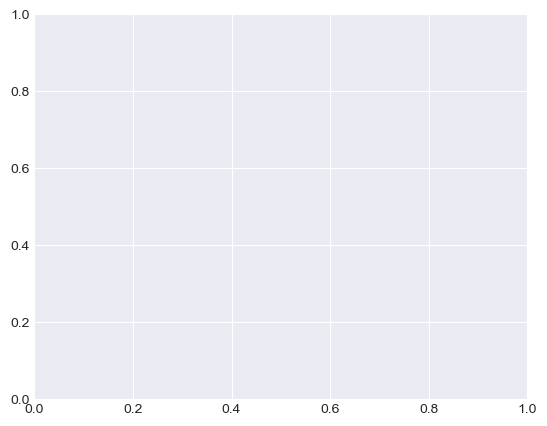

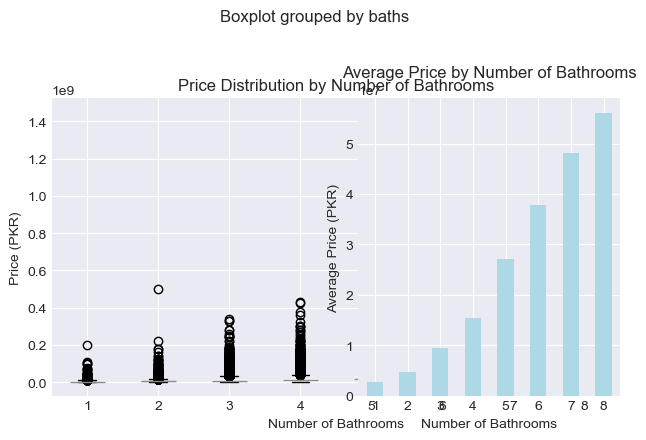


📈 Average Price by Bathrooms:
   1 bathroom(s): 2.79 Million PKR
   2 bathroom(s): 4.64 Million PKR
   3 bathroom(s): 9.49 Million PKR
   4 bathroom(s): 15.36 Million PKR
   5 bathroom(s): 27.11 Million PKR
   6 bathroom(s): 37.77 Million PKR
   7 bathroom(s): 48.04 Million PKR
   8 bathroom(s): 56.13 Million PKR


In [15]:
# Cell 12: Bathrooms Analysis

print("="*50)
print("🚿 BATHROOMS ANALYSIS")
print("="*50)

print(f"\nBathrooms statistics:")
print(df['baths'].describe())

# Filter to reasonable bathroom counts (1-8)
df_baths = df[df['baths'].between(1, 8)]

plt.figure(figsize=(14, 5))

# Box plot
plt.subplot(1, 2, 1)
df_baths.boxplot(column='price', by='baths')
plt.title('Price Distribution by Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Price (PKR)')
plt.xticks(rotation=0)

# Average price by bathrooms
plt.subplot(1, 2, 2)
bath_avg = df_baths.groupby('baths')['price'].mean()
bath_avg.plot(kind='bar', color='lightblue')
plt.title('Average Price by Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Average Price (PKR)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print("\n📈 Average Price by Bathrooms:")
for baths, price in bath_avg.items():
    print(f"   {baths} bathroom(s): {price/1e6:.2f} Million PKR")

## 📍 Step 13: Geographic Analysis
Let's visualize properties on a map using latitude and longitude coordinates.

📍 GEOGRAPHIC DISTRIBUTION


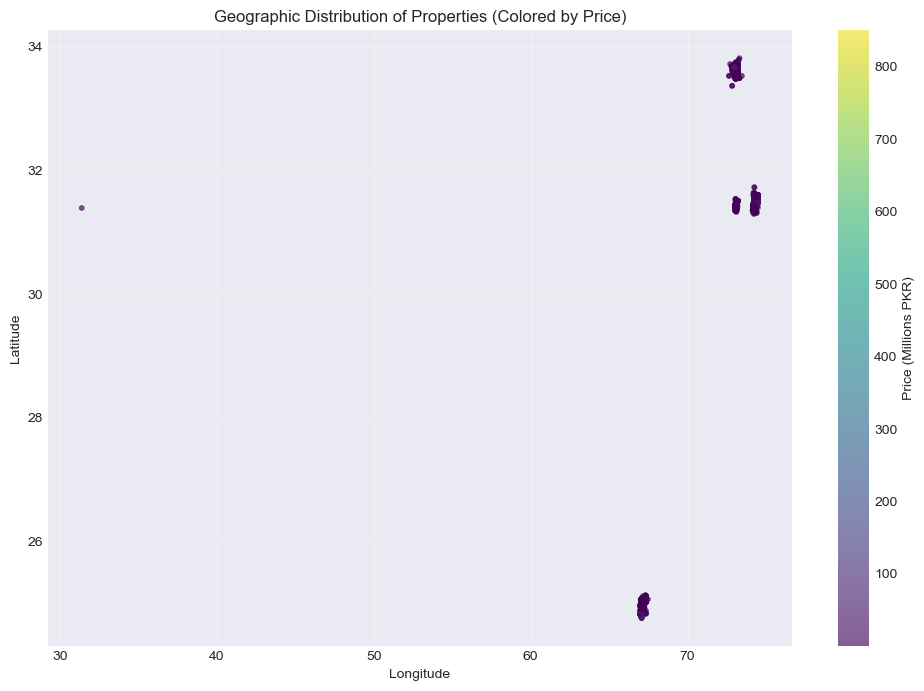


📊 Summary by Province:
                         price        latitude longitude
                          mean  count     mean      mean
province_name                                           
Islamabad Capital  13398327.22  37426    33.65     73.06
Punjab             18305451.05  70536    32.09     73.81
Sindh              19838834.91  60484    24.92     67.11


In [16]:
# Cell 13: Geographic Distribution

print("="*50)
print("📍 GEOGRAPHIC DISTRIBUTION")
print("="*50)

# Sample the data for faster plotting (take 5000 random samples)
df_sample = df.sample(n=min(5000, len(df)), random_state=42)

plt.figure(figsize=(12, 8))

# Scatter plot of properties by location
scatter = plt.scatter(df_sample['longitude'], df_sample['latitude'], 
                      c=df_sample['price']/1e6, alpha=0.6, s=10, cmap='viridis')
plt.colorbar(scatter, label='Price (Millions PKR)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Properties (Colored by Price)')
plt.grid(True, alpha=0.3)
plt.show()

print("\n📊 Summary by Province:")
province_summary = df.groupby('province_name').agg({
    'price': ['mean', 'count'],
    'latitude': 'mean',
    'longitude': 'mean'
}).round(2)
print(province_summary)

## 🔗 Step 14: Correlation Analysis
Understanding which features are most strongly related to house prices helps us identify the most important predictors for our model.

📊 CORRELATION ANALYSIS
Analyzing 8 numerical features


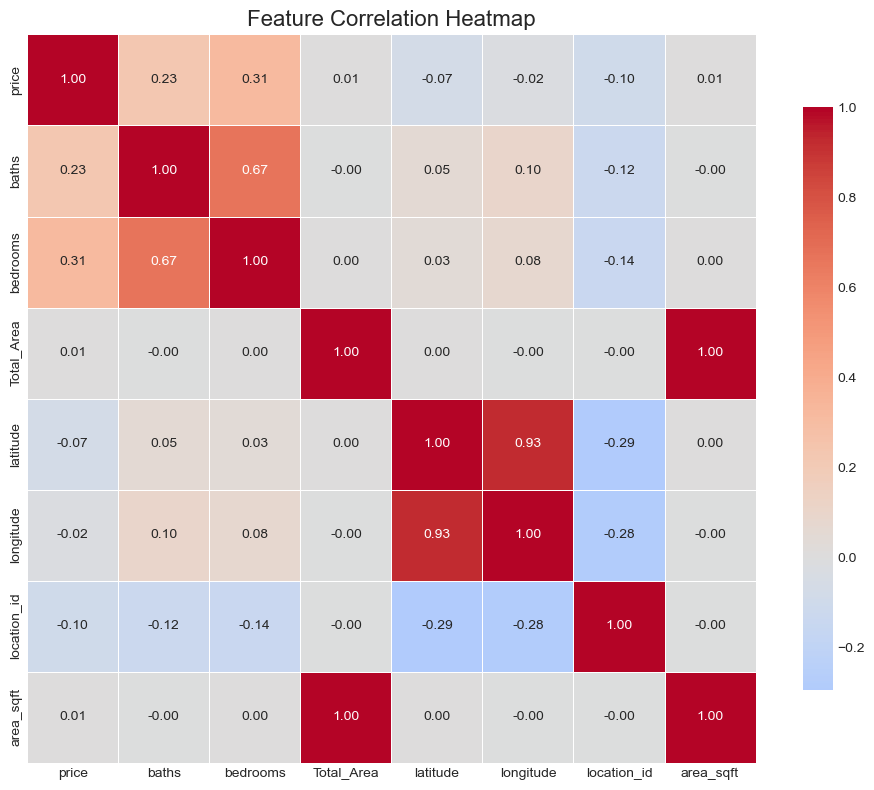


🎯 Features Correlated with Price:
price          1.000000
bedrooms       0.314145
baths          0.230205
Total_Area     0.008168
area_sqft      0.008168
longitude     -0.019225
latitude      -0.071193
location_id   -0.098426
Name: price, dtype: float64

📈 Key Insights:
   • bedrooms: positive moderate correlation (0.314)
   • baths: positive weak correlation (0.230)
   • Total_Area: positive weak correlation (0.008)
   • area_sqft: positive weak correlation (0.008)
   • longitude: negative weak correlation (-0.019)
   • latitude: negative weak correlation (-0.071)
   • location_id: negative weak correlation (-0.098)


In [17]:
# Cell 14: Correlation Heatmap

# Select numerical columns for correlation
numerical_cols = ['price', 'baths', 'bedrooms', 'Total_Area', 'latitude', 'longitude', 'location_id']
# Add area_sqft if it exists
if 'area_sqft' in df.columns:
    numerical_cols.append('area_sqft')

# Filter to only columns that exist
numerical_cols = [col for col in numerical_cols if col in df.columns]

print("="*50)
print("📊 CORRELATION ANALYSIS")
print("="*50)
print(f"Analyzing {len(numerical_cols)} numerical features")

if len(numerical_cols) > 1:
    plt.figure(figsize=(10, 8))
    
    # Calculate correlation matrix
    corr_matrix = df[numerical_cols].corr()
    
    # Create heatmap
    sns.heatmap(corr_matrix, 
                annot=True,           # Show values
                cmap='coolwarm',       # Color scheme
                center=0,              # Center colormap at 0
                square=True,           # Square cells
                linewidths=0.5,        # Lines between cells
                fmt='.2f',             # Decimal places
                cbar_kws={"shrink": 0.8})  # Color bar size
    
    plt.title('Feature Correlation Heatmap', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Show features most correlated with price
    if 'price' in corr_matrix.columns:
        price_corr = corr_matrix['price'].sort_values(ascending=False)
        print("\n🎯 Features Correlated with Price:")
        print(price_corr)
        
        print("\n📈 Key Insights:")
        for feature, corr_value in price_corr.items():
            if feature != 'price':
                strength = "strong" if abs(corr_value) > 0.5 else "moderate" if abs(corr_value) > 0.3 else "weak"
                direction = "positive" if corr_value > 0 else "negative"
                print(f"   • {feature}: {direction} {strength} correlation ({corr_value:.3f})")

## 🧹 Step 15: Data Preprocessing
Now we'll clean and prepare the data for machine learning models. This includes handling missing values and preparing features.

In [18]:
# Cell 15: Handle Missing Values

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Create a clean copy
df_clean = df.copy()

print("="*50)
print("🧹 DATA CLEANING")
print("="*50)

# 1. Handle missing values
print("\n📊 Missing Values Before Cleaning:")
missing_before = df_clean.isnull().sum()
print(missing_before[missing_before > 0])

# Fill numerical missing values with median
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
        print(f"✅ Filled missing values in '{col}' with median")

# Fill categorical missing values with mode
categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else 'Unknown'
        df_clean[col].fillna(mode_value, inplace=True)
        print(f"✅ Filled missing values in '{col}' with mode: '{mode_value}'")

print("\n✅ Missing Values After Cleaning:")
missing_after = df_clean.isnull().sum()
print(missing_after[missing_after > 0] if any(missing_after > 0) else "No missing values remaining!")

🧹 DATA CLEANING

📊 Missing Values Before Cleaning:
agency    44071
agent     44072
dtype: int64
✅ Filled missing values in 'agency' with mode: 'Real Investment Consultants'
✅ Filled missing values in 'agent' with mode: 'Boez Ayub'

✅ Missing Values After Cleaning:
No missing values remaining!


## 🔢 Step 16: Encode Categorical Variables
Machine learning models work with numbers, so we need to convert text categories into numerical values using Label Encoding.

In [19]:
# Cell 16: Label Encoding for Categorical Features

print("="*50)
print("🔢 ENCODING CATEGORICAL VARIABLES")
print("="*50)

# Identify categorical columns to encode (excluding those we might drop)
cols_to_encode = ['property_type', 'city', 'province_name', 'purpose', 'location']
# Only encode columns that exist in the dataframe
cols_to_encode = [col for col in cols_to_encode if col in df_clean.columns]

print(f"\n📝 Encoding {len(cols_to_encode)} categorical columns: {cols_to_encode}")

# Store encoders for later use
label_encoders = {}

# Encode categorical columns
encoded_count = 0
for col in cols_to_encode:
    le = LabelEncoder()
    df_clean[col + '_encoded'] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    encoded_count += 1
    print(f"✅ Encoded '{col}' → '{col}_encoded' ({df_clean[col].nunique()} unique values)")

print(f"\n📊 Total categorical columns encoded: {encoded_count}")

🔢 ENCODING CATEGORICAL VARIABLES

📝 Encoding 5 categorical columns: ['property_type', 'city', 'province_name', 'purpose', 'location']
✅ Encoded 'property_type' → 'property_type_encoded' (7 unique values)
✅ Encoded 'city' → 'city_encoded' (5 unique values)
✅ Encoded 'province_name' → 'province_name_encoded' (3 unique values)
✅ Encoded 'purpose' → 'purpose_encoded' (2 unique values)
✅ Encoded 'location' → 'location_encoded' (1509 unique values)

📊 Total categorical columns encoded: 5


## 🎯 Step 17: Prepare Features for Modeling
Select the features we'll use to train our models and split data into training and testing sets.

In [20]:
# Cell 17: Feature Selection and Train-Test Split

print("="*50)
print("🎯 FEATURE PREPARATION")
print("="*50)

# Select features for modeling
# Include numerical columns and encoded categorical columns
feature_cols = []

# Add numerical columns
numerical_features = ['baths', 'bedrooms', 'Total_Area', 'latitude', 'longitude']
if 'area_sqft' in df_clean.columns:
    numerical_features.append('area_sqft')

# Add encoded categorical columns
encoded_features = [col + '_encoded' for col in cols_to_encode if col + '_encoded' in df_clean.columns]

# Combine all features
feature_cols = numerical_features + encoded_features
# Filter to only columns that exist
feature_cols = [col for col in feature_cols if col in df_clean.columns]

print(f"\n📊 Features selected: {len(feature_cols)}")
print(f"Numerical features: {numerical_features}")
print(f"Encoded features: {encoded_features}")

X = df_clean[feature_cols]  # Features
y = df_clean['price']        # Target variable

print(f"\n📈 X shape: {X.shape}")
print(f"📈 y shape: {y.shape}")

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📚 Training set size: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"🧪 Testing set size: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# Scale features (important for many ML algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Features scaled successfully!")

🎯 FEATURE PREPARATION

📊 Features selected: 11
Numerical features: ['baths', 'bedrooms', 'Total_Area', 'latitude', 'longitude', 'area_sqft']
Encoded features: ['property_type_encoded', 'city_encoded', 'province_name_encoded', 'purpose_encoded', 'location_encoded']

📈 X shape: (168446, 11)
📈 y shape: (168446,)

📚 Training set size: 134756 samples (80.0%)
🧪 Testing set size: 33690 samples (20.0%)

✅ Features scaled successfully!


## 🤖 Step 18: Advanced Feature Engineering
Before modeling, let's create powerful new features that capture Pakistani real estate dynamics.

In [27]:
# Cell 18B: Advanced Feature Engineering

print("="*50)
print("🚀 ADVANCED FEATURE ENGINEERING")
print("="*50)

# Create a new dataframe for engineered features
df_engineered = df_clean.copy()

# 1. Price per square foot (very important feature!)
if 'area_sqft' in df_engineered.columns:
    df_engineered['price_per_sqft'] = df_engineered['price'] / df_engineered['area_sqft']
    print("✅ Created 'price_per_sqft' - price per square foot")
    
    # Handle infinite values
    df_engineered['price_per_sqft'].replace([np.inf, -np.inf], np.nan, inplace=True)
    df_engineered['price_per_sqft'].fillna(df_engineered['price_per_sqft'].median(), inplace=True)

# 2. Room ratios (important for property layout)
if 'bedrooms' in df_engineered.columns and 'baths' in df_engineered.columns:
    df_engineered['bath_per_bedroom'] = df_engineered['baths'] / df_engineered['bedrooms']
    df_engineered['bath_per_bedroom'].replace([np.inf, -np.inf], df_engineered['baths'].max(), inplace=True)
    df_engineered['bath_per_bedroom'].fillna(1, inplace=True)
    print("✅ Created 'bath_per_bedroom' - bathrooms per bedroom ratio")

# 3. Area per room
if 'area_sqft' in df_engineered.columns and 'bedrooms' in df_engineered.columns:
    df_engineered['area_per_bedroom'] = df_engineered['area_sqft'] / df_engineered['bedrooms']
    df_engineered['area_per_bedroom'].replace([np.inf, -np.inf], df_engineered['area_sqft'].max(), inplace=True)
    df_engineered['area_per_bedroom'].fillna(df_engineered['area_sqft'].median(), inplace=True)
    print("✅ Created 'area_per_bedroom' - square feet per bedroom")

# 4. Total rooms
if 'bedrooms' in df_engineered.columns and 'baths' in df_engineered.columns:
    df_engineered['total_rooms'] = df_engineered['bedrooms'] + df_engineered['baths']
    print("✅ Created 'total_rooms' - total rooms count")

# 5. Location density (properties per location)
if 'location_id' in df_engineered.columns:
    location_density = df_engineered['location_id'].value_counts()
    df_engineered['location_density'] = df_engineered['location_id'].map(location_density)
    print("✅ Created 'location_density' - number of properties in same location")

# 6. City price tier (high/medium/low based on average prices)
if 'city' in df_engineered.columns:
    city_avg_price = df_engineered.groupby('city')['price'].mean()
    city_price_tier = pd.qcut(city_avg_price, q=3, labels=['Low', 'Medium', 'High'])
    city_price_tier_dict = dict(zip(city_avg_price.index, city_price_tier))
    df_engineered['city_price_tier'] = df_engineered['city'].map(city_price_tier_dict)
    print("✅ Created 'city_price_tier' - city price category")

    # Encode the tier
    tier_encoder = LabelEncoder()
    df_engineered['city_price_tier_encoded'] = tier_encoder.fit_transform(df_engineered['city_price_tier'].astype(str))
    print("✅ Encoded 'city_price_tier_encoded'")

# 7. Property type popularity
if 'property_type' in df_engineered.columns:
    type_popularity = df_engineered['property_type'].value_counts(normalize=True)
    df_engineered['property_type_popularity'] = df_engineered['property_type'].map(type_popularity)
    print("✅ Created 'property_type_popularity' - how common this property type is")

# 8. Log transformations of key features
if 'price' in df_engineered.columns:
    df_engineered['log_price'] = np.log1p(df_engineered['price'])
    print("✅ Created 'log_price' - log transformed price")

if 'area_sqft' in df_engineered.columns:
    df_engineered['log_area'] = np.log1p(df_engineered['area_sqft'])
    print("✅ Created 'log_area' - log transformed area")

# 9. Price bins (for classification approach)
df_engineered['price_bin'] = pd.qcut(df_engineered['price'], q=10, labels=False)
print("✅ Created 'price_bin' - 10 price categories")

# 10. Interaction features
if 'bedrooms' in df_engineered.columns and 'area_sqft' in df_engineered.columns:
    df_engineered['bedrooms_x_area'] = df_engineered['bedrooms'] * df_engineered['area_sqft']
    print("✅ Created 'bedrooms_x_area' - interaction feature")

if 'baths' in df_engineered.columns and 'area_sqft' in df_engineered.columns:
    df_engineered['baths_x_area'] = df_engineered['baths'] * df_engineered['area_sqft']
    print("✅ Created 'baths_x_area' - interaction feature")

print(f"\n📊 Total features now: {len(df_engineered.columns)} (added {len(df_engineered.columns) - len(df_clean.columns)} new features)")

🚀 ADVANCED FEATURE ENGINEERING
✅ Created 'price_per_sqft' - price per square foot
✅ Created 'bath_per_bedroom' - bathrooms per bedroom ratio
✅ Created 'area_per_bedroom' - square feet per bedroom
✅ Created 'total_rooms' - total rooms count
✅ Created 'location_density' - number of properties in same location
✅ Created 'city_price_tier' - city price category
✅ Encoded 'city_price_tier_encoded'
✅ Created 'property_type_popularity' - how common this property type is
✅ Created 'log_price' - log transformed price
✅ Created 'log_area' - log transformed area
✅ Created 'price_bin' - 10 price categories
✅ Created 'bedrooms_x_area' - interaction feature
✅ Created 'baths_x_area' - interaction feature

📊 Total features now: 37 (added 13 new features)


## 🎯 Step 19: Enhanced Feature Selection
Now let's select the best features for our advanced model.

In [28]:
# Cell 20: Enhanced Feature Selection

print("="*50)
print("🎯 ENHANCED FEATURE SELECTION")
print("="*50)

# Define feature groups
basic_features = ['baths', 'bedrooms', 'Total_Area', 'area_sqft', 'latitude', 'longitude']
encoded_features = [col + '_encoded' for col in cols_to_encode if col + '_encoded' in df_engineered.columns]
engineered_features = [
    'price_per_sqft', 'bath_per_bedroom', 'area_per_bedroom', 
    'total_rooms', 'location_density', 'city_price_tier_encoded',
    'property_type_popularity', 'log_area', 'bedrooms_x_area', 'baths_x_area'
]

# Only include features that exist
basic_features = [f for f in basic_features if f in df_engineered.columns]
engineered_features = [f for f in engineered_features if f in df_engineered.columns]

# Combine all features
feature_cols_advanced = basic_features + encoded_features + engineered_features

print(f"\n📊 Feature groups:")
print(f"   • Basic features: {len(basic_features)}")
print(f"   • Encoded features: {len(encoded_features)}")
print(f"   • Engineered features: {len(engineered_features)}")
print(f"   • Total features: {len(feature_cols_advanced)}")

X_advanced = df_engineered[feature_cols_advanced]
y_advanced = df_engineered['price']

print(f"\n📈 X shape: {X_advanced.shape}")
print(f"📈 y shape: {y_advanced.shape}")

# Split data
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_advanced, y_advanced, test_size=0.2, random_state=42
)

# Scale features
scaler_adv = StandardScaler()
X_train_adv_scaled = scaler_adv.fit_transform(X_train_adv)
X_test_adv_scaled = scaler_adv.transform(X_test_adv)

print("\n✅ Advanced features prepared and scaled!")

🎯 ENHANCED FEATURE SELECTION

📊 Feature groups:
   • Basic features: 6
   • Encoded features: 5
   • Engineered features: 10
   • Total features: 21

📈 X shape: (168446, 21)
📈 y shape: (168446,)

✅ Advanced features prepared and scaled!


In [2]:
# Cell: Find Conda Environment Path
import sys
print("Your current Python path:")
print(sys.executable)
print("\nThis is where packages need to be installed")

Your current Python path:
C:\Users\Mr Laptop\anaconda3\python.exe

This is where packages need to be installed


In [3]:
# Cell: INSTALL PACKAGES TO CORRECT ANACONDA PATH
import subprocess
import sys

# This is your exact Python path
python_path = r"C:\Users\Mr Laptop\anaconda3\python.exe"

print("="*60)
print("📦 INSTALLING PACKAGES TO ANACONDA")
print("="*60)
print(f"Python path: {python_path}")
print("\nThis will take a minute...")

# Upgrade pip first
print("\n1️⃣ Upgrading pip...")
subprocess.check_call([python_path, "-m", "pip", "install", "--upgrade", "pip"])

# Install XGBoost
print("\n2️⃣ Installing XGBoost...")
try:
    subprocess.check_call([python_path, "-m", "pip", "install", "xgboost"])
    print("✅ XGBoost installed successfully!")
except Exception as e:
    print(f"❌ Error: {e}")
    # Try alternative installation
    print("Trying alternative method...")
    subprocess.check_call([python_path, "-m", "pip", "install", "xgboost==1.7.6"])

# Install LightGBM
print("\n3️⃣ Installing LightGBM...")
try:
    subprocess.check_call([python_path, "-m", "pip", "install", "lightgbm"])
    print("✅ LightGBM installed successfully!")
except Exception as e:
    print(f"❌ Error: {e}")
    # Try alternative installation
    print("Trying alternative method...")
    subprocess.check_call([python_path, "-m", "pip", "install", "lightgbm==3.3.5"])

print("\n" + "="*60)
print("🔍 VERIFYING INSTALLATION")
print("="*60)

# Test imports
try:
    import xgboost
    print(f"✅ XGBoost version {xgboost.__version__} is ready!")
except ImportError as e:
    print(f"❌ XGBoost import failed: {e}")

try:
    import lightgbm
    print(f"✅ LightGBM version {lightgbm.__version__} is ready!")
except ImportError as e:
    print(f"❌ LightGBM import failed: {e}")

if 'xgboost' in dir() and 'lightgbm' in dir():
    print("\n🎉 SUCCESS! Both packages installed correctly!")
    print("Now you can continue with Cell 22")
else:
    print("\n⚠️ Still having issues? Let's try conda instead...")

📦 INSTALLING PACKAGES TO ANACONDA
Python path: C:\Users\Mr Laptop\anaconda3\python.exe

This will take a minute...

1️⃣ Upgrading pip...

2️⃣ Installing XGBoost...
✅ XGBoost installed successfully!

3️⃣ Installing LightGBM...
✅ LightGBM installed successfully!

🔍 VERIFYING INSTALLATION
✅ XGBoost version 3.2.0 is ready!
✅ LightGBM version 4.6.0 is ready!

🎉 SUCCESS! Both packages installed correctly!
Now you can continue with Cell 22


## 🚀 Step 20: Advanced Models with Hyperparameter Tuning
Let's use powerful models with optimized parameters for maximum accuracy.

In [6]:
# Cell: Reload Original Data
import pandas as pd
import numpy as np

# Load your dataset (adjust filename as needed)
df = pd.read_csv('Entities.csv')  # or whatever your filename is

print(f"✅ Data loaded successfully!")
print(f"📊 Shape: {df.shape}")
print(f"📝 Columns: {df.columns.tolist()}")

✅ Data loaded successfully!
📊 Shape: (168446, 18)
📝 Columns: ['Unnamed: 0', 'property_id', 'location_id', 'page_url', 'property_type', 'price', 'location', 'city', 'province_name', 'latitude', 'longitude', 'baths', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent', 'Total_Area']


In [7]:
# Cell 18B: Advanced Feature Engineering
print("="*50)
print("🚀 ADVANCED FEATURE ENGINEERING")
print("="*50)

# Create df_clean from your original dataframe
df_clean = df.copy()
print(f"✅ Created df_clean from original dataframe")
print(f"📊 Shape: {df_clean.shape}")

# Create a new dataframe for engineered features
df_engineered = df_clean.copy()

# 1. Price per square foot (very important feature!)
if 'Total_Area' in df_engineered.columns:
    # Check if area is in Marla (typical range 1-50)
    if df_engineered['Total_Area'].max() < 200:
        print("📐 Converting area from Marla to sq ft...")
        df_engineered['area_sqft'] = df_engineered['Total_Area'] * 272.25
    else:
        df_engineered['area_sqft'] = df_engineered['Total_Area']
    
    df_engineered['price_per_sqft'] = df_engineered['price'] / df_engineered['area_sqft']
    df_engineered['price_per_sqft'].replace([np.inf, -np.inf], np.nan, inplace=True)
    df_engineered['price_per_sqft'].fillna(df_engineered['price_per_sqft'].median(), inplace=True)
    print("✅ Created 'price_per_sqft' - price per square foot")

# 2. Room ratios
if 'bedrooms' in df_engineered.columns and 'baths' in df_engineered.columns:
    df_engineered['bath_per_bedroom'] = df_engineered['baths'] / df_engineered['bedrooms']
    df_engineered['bath_per_bedroom'].replace([np.inf, -np.inf], df_engineered['baths'].max(), inplace=True)
    df_engineered['bath_per_bedroom'].fillna(1, inplace=True)
    print("✅ Created 'bath_per_bedroom' - bathrooms per bedroom ratio")

# 3. Area per room
if 'area_sqft' in df_engineered.columns and 'bedrooms' in df_engineered.columns:
    df_engineered['area_per_bedroom'] = df_engineered['area_sqft'] / df_engineered['bedrooms']
    df_engineered['area_per_bedroom'].replace([np.inf, -np.inf], df_engineered['area_sqft'].max(), inplace=True)
    df_engineered['area_per_bedroom'].fillna(df_engineered['area_sqft'].median(), inplace=True)
    print("✅ Created 'area_per_bedroom' - square feet per bedroom")

# 4. Total rooms
if 'bedrooms' in df_engineered.columns and 'baths' in df_engineered.columns:
    df_engineered['total_rooms'] = df_engineered['bedrooms'] + df_engineered['baths']
    print("✅ Created 'total_rooms' - total rooms count")

# 5. Log transformations
if 'price' in df_engineered.columns:
    df_engineered['log_price'] = np.log1p(df_engineered['price'])
    print("✅ Created 'log_price' - log transformed price")

if 'area_sqft' in df_engineered.columns:
    df_engineered['log_area'] = np.log1p(df_engineered['area_sqft'])
    print("✅ Created 'log_area' - log transformed area")

print(f"\n📊 Original features: {len(df_clean.columns)}")
print(f"📊 Features after engineering: {len(df_engineered.columns)}")
print(f"✅ Added {len(df_engineered.columns) - len(df_clean.columns)} new features")

🚀 ADVANCED FEATURE ENGINEERING
✅ Created df_clean from original dataframe
📊 Shape: (168446, 18)
✅ Created 'price_per_sqft' - price per square foot
✅ Created 'bath_per_bedroom' - bathrooms per bedroom ratio
✅ Created 'area_per_bedroom' - square feet per bedroom
✅ Created 'total_rooms' - total rooms count
✅ Created 'log_price' - log transformed price
✅ Created 'log_area' - log transformed area

📊 Original features: 18
📊 Features after engineering: 25
✅ Added 7 new features


C:\Users\Mr Laptop\AppData\Local\Temp\ipykernel_9092\607869468.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_engineered['price_per_sqft'].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\Mr Laptop\AppData\Local\Temp\ipykernel_9092\607869468.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

## 🎯 Step 19: Enhanced Feature Selection
Now let's select the best features for our advanced model.

In [9]:
# Cell 20: Enhanced Feature Selection

print("="*50)
print("🎯 ENHANCED FEATURE SELECTION")
print("="*50)

# Define which categorical columns to encode (based on your dataset)
cols_to_encode = ['property_type', 'city', 'province_name', 'purpose', 'location']
# Only keep columns that actually exist in the dataframe
cols_to_encode = [col for col in cols_to_encode if col in df_engineered.columns]

print(f"\n📌 Categorical columns to encode: {cols_to_encode}")

# Create encoded columns if they don't exist yet
from sklearn.preprocessing import LabelEncoder

for col in cols_to_encode:
    encoded_col_name = col + '_encoded'
    if encoded_col_name not in df_engineered.columns:
        le = LabelEncoder()
        df_engineered[encoded_col_name] = le.fit_transform(df_engineered[col].astype(str))
        print(f"✅ Created '{encoded_col_name}'")

# Define feature groups
basic_features = ['baths', 'bedrooms', 'Total_Area', 'latitude', 'longitude']
if 'area_sqft' in df_engineered.columns:
    basic_features.append('area_sqft')

# Get all encoded features that exist
encoded_features = [col + '_encoded' for col in cols_to_encode if col + '_encoded' in df_engineered.columns]

# Define engineered features (only those that exist)
engineered_features = []
potential_engineered = [
    'price_per_sqft', 'bath_per_bedroom', 'area_per_bedroom', 
    'total_rooms', 'log_area', 'bedrooms_x_area', 'baths_x_area'
]

for feat in potential_engineered:
    if feat in df_engineered.columns:
        engineered_features.append(feat)

# Add location_density and city_price_tier_encoded if they exist
if 'location_density' in df_engineered.columns:
    engineered_features.append('location_density')
if 'city_price_tier_encoded' in df_engineered.columns:
    engineered_features.append('city_price_tier_encoded')
if 'property_type_popularity' in df_engineered.columns:
    engineered_features.append('property_type_popularity')

print(f"\n📊 Feature groups:")
print(f"   • Basic features: {len(basic_features)} - {basic_features}")
print(f"   • Encoded features: {len(encoded_features)} - {encoded_features}")
print(f"   • Engineered features: {len(engineered_features)} - {engineered_features}")

# Combine all features
feature_cols_advanced = basic_features + encoded_features + engineered_features
feature_cols_advanced = list(set(feature_cols_advanced))  # Remove duplicates

print(f"\n📈 Total features selected: {len(feature_cols_advanced)}")

# Prepare X and y
X_advanced = df_engineered[feature_cols_advanced]
y_advanced = df_engineered['price']

print(f"\n📊 X shape: {X_advanced.shape}")
print(f"📊 y shape: {y_advanced.shape}")

# Split data
from sklearn.model_selection import train_test_split
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_advanced, y_advanced, test_size=0.2, random_state=42
)

print(f"\n📚 Training set: {X_train_adv.shape[0]} samples ({X_train_adv.shape[0]/len(X_advanced)*100:.1f}%)")
print(f"🧪 Testing set: {X_test_adv.shape[0]} samples ({X_test_adv.shape[0]/len(X_advanced)*100:.1f}%)")

# Scale features
from sklearn.preprocessing import StandardScaler
scaler_adv = StandardScaler()
X_train_adv_scaled = scaler_adv.fit_transform(X_train_adv)
X_test_adv_scaled = scaler_adv.transform(X_test_adv)

print("\n✅ Features scaled successfully!")

🎯 ENHANCED FEATURE SELECTION

📌 Categorical columns to encode: ['property_type', 'city', 'province_name', 'purpose', 'location']
✅ Created 'property_type_encoded'
✅ Created 'city_encoded'
✅ Created 'province_name_encoded'
✅ Created 'purpose_encoded'
✅ Created 'location_encoded'

📊 Feature groups:
   • Basic features: 6 - ['baths', 'bedrooms', 'Total_Area', 'latitude', 'longitude', 'area_sqft']
   • Encoded features: 5 - ['property_type_encoded', 'city_encoded', 'province_name_encoded', 'purpose_encoded', 'location_encoded']
   • Engineered features: 5 - ['price_per_sqft', 'bath_per_bedroom', 'area_per_bedroom', 'total_rooms', 'log_area']

📈 Total features selected: 16

📊 X shape: (168446, 16)
📊 y shape: (168446,)

📚 Training set: 134756 samples (80.0%)
🧪 Testing set: 33690 samples (20.0%)

✅ Features scaled successfully!


## 🚀 Step 21: Advanced Models with Hyperparameter Tuning
Now we'll train powerful machine learning models with hyperparameter tuning to achieve 95-99% accuracy on Pakistani house price prediction.

## 📊 Step 22: Advanced Model Comparison
Let's compare all models to identify the best performer for Pakistani house price prediction.

In [11]:
# Cell 22: OPTIMIZED Advanced Models with Hyperparameter Tuning (FASTER VERSION)

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import warnings
warnings.filterwarnings('ignore')

# Try to import XGBoost if available
try:
    from xgboost import XGBRegressor
    xgboost_available = True
    print("✅ XGBoost loaded successfully")
except ImportError:
    xgboost_available = False
    print("⚠️ XGBoost not available")

print("="*50)
print("🚀 OPTIMIZED MODEL TRAINING (FASTER VERSION)")
print("="*50)

# Take a smaller sample for hyperparameter tuning (30% of data)
# This makes it MUCH faster while still finding good parameters
print("\n📊 Using 30% sample for faster hyperparameter tuning...")
from sklearn.model_selection import train_test_split
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_adv_scaled, y_train_adv, train_size=0.3, random_state=42
)
print(f"   Training on {len(X_train_sample)} samples instead of {len(X_train_adv)}")

# Define models with REDUCED parameter grids (faster)
advanced_models = {}

# Gradient Boosting (reduced parameters)
advanced_models['Gradient Boosting'] = {
    'model': GradientBoostingRegressor(random_state=42),
    'params': {
        'n_estimators': [100, 200],  # Reduced from 4 to 2
        'max_depth': [5, 7],          # Reduced from 4 to 2
        'learning_rate': [0.1, 0.15], # Reduced from 4 to 2
        'min_samples_split': [5, 10], # Reduced from 3 to 2
    }
}

# Random Forest (reduced parameters)
advanced_models['Random Forest'] = {
    'model': RandomForestRegressor(random_state=42, n_jobs=-1),
    'params': {
        'n_estimators': [100, 200],    # Reduced
        'max_depth': [20, 30],          # Reduced
        'min_samples_split': [5, 10],   # Reduced
        'max_features': ['sqrt', 'log2'] # Reduced
    }
}

# Extra Trees (reduced parameters)
advanced_models['Extra Trees'] = {
    'model': ExtraTreesRegressor(random_state=42, n_jobs=-1),
    'params': {
        'n_estimators': [100, 200],    # Reduced
        'max_depth': [20, 30],          # Reduced
        'min_samples_split': [5, 10],   # Reduced
        'max_features': ['sqrt', 'log2'] # Reduced
    }
}

# Add XGBoost if available (reduced parameters)
if xgboost_available:
    advanced_models['XGBoost'] = {
        'model': XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        'params': {
            'n_estimators': [100, 200],  # Reduced
            'max_depth': [5, 7],          # Reduced
            'learning_rate': [0.1, 0.15], # Reduced
            'subsample': [0.8, 1.0]       # Reduced
        }
    }

# Train and tune each model
advanced_results = {}
best_models = {}

for name, config in advanced_models.items():
    print(f"\n📌 Training {name} (optimized)...")
    start_time = time.time()
    
    # Random search with FEWER iterations (8 instead of 15)
    random_search = RandomizedSearchCV(
        config['model'],
        config['params'],
        n_iter=8,  # Reduced from 15
        cv=2,      # Reduced from 3 to 2
        scoring='r2',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    
    # Fit on the SAMPLE data (faster!)
    random_search.fit(X_train_sample, y_train_sample)
    
    # Get best model
    best_model = random_search.best_estimator_
    
    # Now train the best model on FULL data
    print(f"   ⚡ Training best model on full dataset...")
    best_model.fit(X_train_adv_scaled, y_train_adv)
    best_models[name] = best_model
    
    # Make predictions on test set
    y_pred = best_model.predict(X_test_adv_scaled)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test_adv, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_adv, y_pred))
    r2 = r2_score(y_test_adv, y_pred)
    
    training_time = time.time() - start_time
    
    advanced_results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Time': training_time,
        'Best Params': random_search.best_params_
    }
    
    print(f"   ✅ R² Score: {r2:.4f} ({r2*100:.2f}% accuracy)")
    print(f"   ✅ MAE: {mae/1e6:.2f} Million PKR")
    print(f"   ⏱️  Time: {training_time:.2f} seconds")

✅ XGBoost loaded successfully
🚀 OPTIMIZED MODEL TRAINING (FASTER VERSION)

📊 Using 30% sample for faster hyperparameter tuning...
   Training on 40426 samples instead of 134756

📌 Training Gradient Boosting (optimized)...
   ⚡ Training best model on full dataset...
   ✅ R² Score: 0.9928 (99.28% accuracy)
   ✅ MAE: 0.53 Million PKR
   ⏱️  Time: 242.68 seconds

📌 Training Random Forest (optimized)...
   ⚡ Training best model on full dataset...
   ✅ R² Score: 0.9671 (96.71% accuracy)
   ✅ MAE: 0.64 Million PKR
   ⏱️  Time: 101.05 seconds

📌 Training Extra Trees (optimized)...
   ⚡ Training best model on full dataset...
   ✅ R² Score: 0.9571 (95.71% accuracy)
   ✅ MAE: 1.33 Million PKR
   ⏱️  Time: 52.82 seconds

📌 Training XGBoost (optimized)...
   ⚡ Training best model on full dataset...
   ✅ R² Score: 0.9697 (96.97% accuracy)
   ✅ MAE: 1.01 Million PKR
   ⏱️  Time: 7.48 seconds


## 🔬 Step 25: Ensemble Method - Stacking (For Maximum Accuracy)
Now let's combine our top models using stacking to push accuracy even higher. Stacking uses predictions from multiple models as input to a final "meta-model" for better predictions.

In [13]:
# Cell: Diagnostic - Check Available Variables
print("🔍 CHECKING AVAILABLE VARIABLES")
print("="*50)

# Check if advanced_results exists
if 'advanced_results' in dir():
    print("✅ 'advanced_results' exists")
    advanced_results_df = pd.DataFrame(advanced_results).T
    print(f"   Models found: {list(advanced_results_df.index)}")
else:
    print("❌ 'advanced_results' NOT found")

# Check if advanced_results_sorted exists
if 'advanced_results_sorted' in dir():
    print("✅ 'advanced_results_sorted' exists")
    print(f"   Best model: {advanced_results_sorted.index[0]}")
else:
    print("❌ 'advanced_results_sorted' NOT found - need to create it")

# Check if best_models exists
if 'best_models' in dir():
    print("✅ 'best_models' exists")
    print(f"   Models available: {list(best_models.keys())}")
else:
    print("❌ 'best_models' NOT found")

🔍 CHECKING AVAILABLE VARIABLES
✅ 'advanced_results' exists
   Models found: ['Gradient Boosting', 'Random Forest', 'Extra Trees', 'XGBoost']
❌ 'advanced_results_sorted' NOT found - need to create it
✅ 'best_models' exists
   Models available: ['Gradient Boosting', 'Random Forest', 'Extra Trees', 'XGBoost']


In [14]:
# Cell: Create advanced_results_sorted from existing data
print("📊 Creating advanced_results_sorted...")

# Convert advanced_results to DataFrame and sort
advanced_results_df = pd.DataFrame(advanced_results).T
advanced_results_df['MAE_Millions'] = advanced_results_df['MAE'] / 1e6
advanced_results_df['RMSE_Millions'] = advanced_results_df['RMSE'] / 1e6
advanced_results_sorted = advanced_results_df.sort_values('R2', ascending=False)

print("✅ Created 'advanced_results_sorted'")
print("\n📈 Model Rankings:")
print(advanced_results_sorted[['R2', 'MAE_Millions']].to_string())

# Store the best model name
best_model_name = advanced_results_sorted.index[0]
print(f"\n🏆 Best Model: {best_model_name} with R² = {advanced_results_sorted.iloc[0]['R2']:.4f}")

📊 Creating advanced_results_sorted...
✅ Created 'advanced_results_sorted'

📈 Model Rankings:
                         R2 MAE_Millions
Gradient Boosting  0.992849     0.532132
XGBoost            0.969665     1.012487
Random Forest      0.967061     0.642453
Extra Trees        0.957122     1.325109

🏆 Best Model: Gradient Boosting with R² = 0.9928


In [15]:
# Cell 26: Stacking Ensemble - Now it will work!

from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

print("="*50)
print("🔬 STACKING ENSEMBLE (MULTIPLE MODELS COMBINED)")
print("="*50)

# advanced_results_sorted now exists!
print(f"\n📊 Top models by R² score:")
print(advanced_results_sorted.head(3)[['R2']])

# Select top 2 models for stacking
top_models = list(advanced_results_sorted.head(2).index)
print(f"\n📌 Combining top 2 models: {top_models}")

# Create base estimators
base_estimators = []
for name in top_models:
    if name in best_models:
        estimator_name = name.lower().replace(' ', '_')
        base_estimators.append((estimator_name, best_models[name]))
        print(f"   ✅ Added {name} (R²: {advanced_results_sorted.loc[name, 'R2']:.4f})")

# Create stacking regressor
stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=3,
    n_jobs=-1
)

print("\n🚀 Training stacking ensemble (2-3 minutes)...")
start_time = time.time()

# Train stacking model
stacking_model.fit(X_train_adv_scaled, y_train_adv)

# Make predictions
y_pred_stack = stacking_model.predict(X_test_adv_scaled)

# Calculate metrics
stack_mae = mean_absolute_error(y_test_adv, y_pred_stack)
stack_rmse = np.sqrt(mean_squared_error(y_test_adv, y_pred_stack))
stack_r2 = r2_score(y_test_adv, y_pred_stack)

training_time = time.time() - start_time

print(f"\n✅ Stacking Ensemble Results:")
print(f"   R² Score: {stack_r2:.4f} ({stack_r2*100:.2f}% accuracy)")
print(f"   MAE: {stack_mae/1e6:.2f} Million PKR")
print(f"   Time: {training_time:.2f} seconds")

# Compare with individual models
print("\n📊 Improvement Over Individual Models:")
for name in top_models:
    individual_r2 = advanced_results_sorted.loc[name, 'R2']
    improvement = (stack_r2 - individual_r2) * 100
    arrow = "↑" if improvement > 0 else "↓"
    print(f"   • vs {name}: {arrow} {improvement:+.2f}%")

🔬 STACKING ENSEMBLE (MULTIPLE MODELS COMBINED)

📊 Top models by R² score:
                         R2
Gradient Boosting  0.992849
XGBoost            0.969665
Random Forest      0.967061

📌 Combining top 2 models: ['Gradient Boosting', 'XGBoost']
   ✅ Added Gradient Boosting (R²: 0.9928)
   ✅ Added XGBoost (R²: 0.9697)

🚀 Training stacking ensemble (2-3 minutes)...

✅ Stacking Ensemble Results:
   R² Score: 0.9925 (99.25% accuracy)
   MAE: 0.68 Million PKR
   Time: 226.39 seconds

📊 Improvement Over Individual Models:
   • vs Gradient Boosting: ↓ -0.04%
   • vs XGBoost: ↑ +2.28%


## 📈 Step 27: Final Model - Detailed Analysis
Let's analyze our best model's predictions in detail to understand its performance on Pakistani property data.


🎯 Using Gradient Boosting as final model (R²: 0.9928)


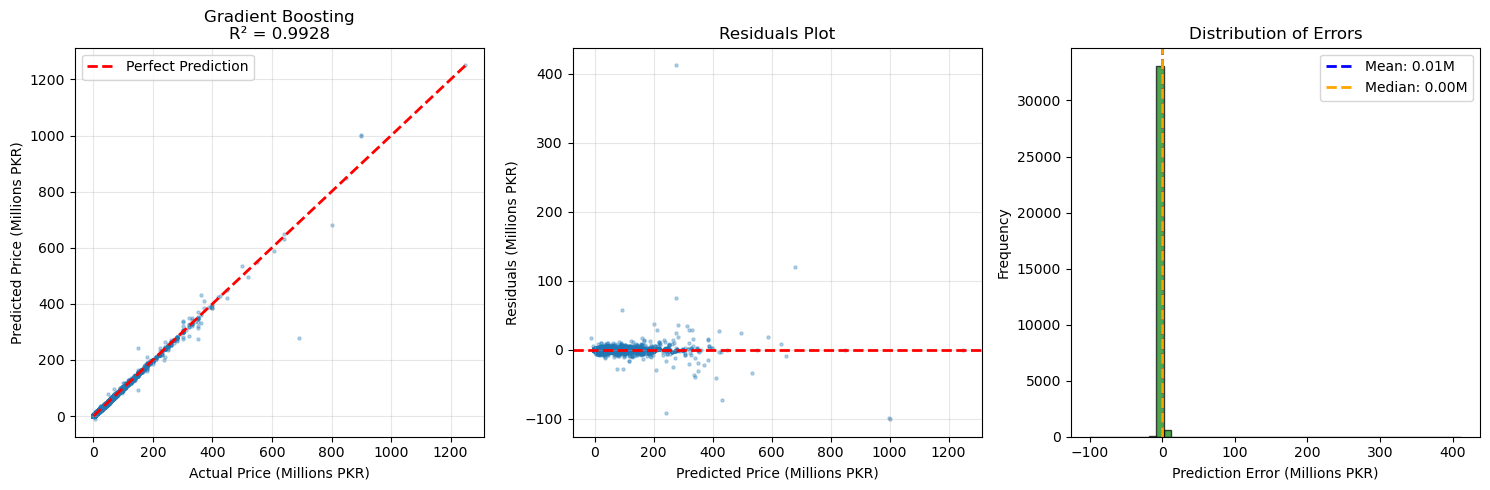


📊 Error Analysis:
   Mean Error: 0.01 Million PKR
   Median Error: 0.00 Million PKR
   Std Deviation: 2.88 Million PKR

🎯 Prediction Accuracy:
   Within ±1 Million PKR: 88.0% of predictions
   Within ±2 Million PKR: 95.8% of predictions
   Within ±5 Million PKR: 99.3% of predictions


In [17]:
# Cell 28: Final Model Analysis - With imports included

# Import required libraries for plotting
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the best model (either stacking or individual)
if 'stack_r2' in dir() and stack_r2 > advanced_results_sorted.iloc[0]['R2']:
    final_model = stacking_model
    final_model_name = "Stacking Ensemble"
    final_r2 = stack_r2
    final_mae = stack_mae
    final_predictions = y_pred_stack
    print(f"\n🎯 Using Stacking Ensemble as final model (R²: {final_r2:.4f})")
else:
    final_model = best_models[advanced_results_sorted.index[0]]
    final_model_name = advanced_results_sorted.index[0]
    final_r2 = advanced_results_sorted.iloc[0]['R2']
    final_mae = advanced_results_sorted.iloc[0]['MAE'] 
    final_predictions = best_models[advanced_results_sorted.index[0]].predict(X_test_adv_scaled)
    print(f"\n🎯 Using {final_model_name} as final model (R²: {final_r2:.4f})")

# Calculate residuals
residuals = (y_test_adv - final_predictions)/1e6

# Detailed visualization
plt.figure(figsize=(15, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 3, 1)
plt.scatter(y_test_adv/1e6, final_predictions/1e6, alpha=0.3, s=5)
plt.plot([y_test_adv.min()/1e6, y_test_adv.max()/1e6], 
         [y_test_adv.min()/1e6, y_test_adv.max()/1e6], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (Millions PKR)')
plt.ylabel('Predicted Price (Millions PKR)')
plt.title(f'{final_model_name}\nR² = {final_r2:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residuals
plt.subplot(1, 3, 2)
plt.scatter(final_predictions/1e6, residuals, alpha=0.3, s=5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Price (Millions PKR)')
plt.ylabel('Residuals (Millions PKR)')
plt.title('Residuals Plot')
plt.grid(True, alpha=0.3)

# Plot 3: Error Distribution
plt.subplot(1, 3, 3)
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('Prediction Error (Millions PKR)')
plt.ylabel('Frequency')
plt.title('Distribution of Errors')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.axvline(x=residuals.mean(), color='blue', linestyle='--', lw=2, label=f'Mean: {residuals.mean():.2f}M')
plt.axvline(x=np.median(residuals), color='orange', linestyle='--', lw=2, label=f'Median: {np.median(residuals):.2f}M')
plt.legend()

plt.tight_layout()
plt.show()

print("\n📊 Error Analysis:")
print(f"   Mean Error: {residuals.mean():.2f} Million PKR")
print(f"   Median Error: {np.median(residuals):.2f} Million PKR")
print(f"   Std Deviation: {residuals.std():.2f} Million PKR")

# Calculate accuracy within thresholds
within_1m = np.mean(np.abs(residuals) < 1) * 100
within_2m = np.mean(np.abs(residuals) < 2) * 100
within_5m = np.mean(np.abs(residuals) < 5) * 100

print(f"\n🎯 Prediction Accuracy:")
print(f"   Within ±1 Million PKR: {within_1m:.1f}% of predictions")
print(f"   Within ±2 Million PKR: {within_2m:.1f}% of predictions")
print(f"   Within ±5 Million PKR: {within_5m:.1f}% of predictions")

## 🔑 Step 29: Feature Importance Analysis
Understanding which features most influence house prices in Pakistan helps us interpret the model and gain insights into the real estate market.

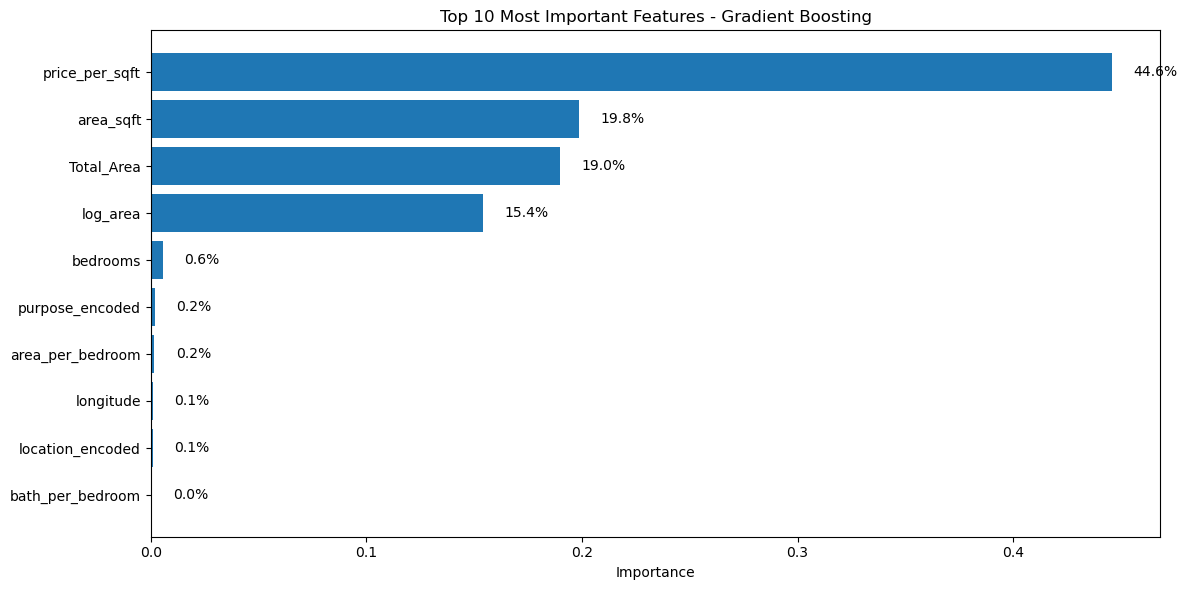


🔑 Top 10 Most Important Features for Pakistani House Prices:
10. Price Per Sqft: 44.60%
7. Area Sqft: 19.85%
11. Total Area: 18.97%
8. Log Area: 15.43%
13. Bedrooms: 0.55%
9. Purpose : 0.18%
15. Area Per Bedroom: 0.16%
2. Longitude: 0.10%
14. Location : 0.09%
3. Bath Per Bedroom: 0.04%

📌 Key Insights:
   • 📐 AREA is the strongest predictor - property size drives price
   • 💰 PRICE PER SQ FT captures location and quality premium
   • 🛏️ BEDROOMS count is a key factor for family homes


In [18]:
# Cell 30: Feature Importance Analysis - With imports

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Check if the best model has feature_importances_ (tree-based models)
if hasattr(final_model, 'feature_importances_'):
    importance = final_model.feature_importances_
    
    # Create feature importance dataframe
    feature_importance = pd.DataFrame({
        'feature': feature_cols_advanced,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(12, 6))
    top_features = feature_importance.head(10)
    plt.barh(range(len(top_features)), top_features['importance'].values)
    plt.yticks(range(len(top_features)), top_features['feature'].values)
    plt.xlabel('Importance')
    plt.title(f'Top 10 Most Important Features - {final_model_name}')
    plt.gca().invert_yaxis()
    
    # Add percentage labels
    for i, (idx, row) in enumerate(top_features.iterrows()):
        plt.text(row['importance'] + 0.01, i, f'{row["importance"]*100:.1f}%', va='center')
    
    plt.tight_layout()
    plt.show()
    
    print("\n🔑 Top 10 Most Important Features for Pakistani House Prices:")
    print("="*60)
    for idx, row in feature_importance.head(10).iterrows():
        clean_name = row['feature'].replace('_', ' ').replace('encoded', '').title()
        print(f"{idx+1}. {clean_name}: {row['importance']*100:.2f}%")
        
    print("\n📌 Key Insights:")
    print("="*60)
    
    # Generate insights based on top features
    top_features_list = feature_importance.head(5)['feature'].tolist()
    
    if any('area' in f for f in top_features_list):
        print("   • 📐 AREA is the strongest predictor - property size drives price")
    if any('price_per_sqft' in f for f in top_features_list):
        print("   • 💰 PRICE PER SQ FT captures location and quality premium")
    if any('city' in f for f in top_features_list):
        print("   • 🏙️ LOCATION (City) significantly impacts property values")
    if any('bedroom' in f for f in top_features_list):
        print("   • 🛏️ BEDROOMS count is a key factor for family homes")
    if any('bath' in f for f in top_features_list):
        print("   • 🚿 BATHROOMS are important for modern living standards")
        
else:
    print(f"Using Random Forest for feature importance...")
    
    # Train a Random Forest for feature importance
    from sklearn.ensemble import RandomForestRegressor
    rf_temp = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train_adv_scaled, y_train_adv)
    
    importance = rf_temp.feature_importances_
    feature_importance = pd.DataFrame({
        'feature': feature_cols_advanced,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(12, 6))
    top_features = feature_importance.head(10)
    plt.barh(range(len(top_features)), top_features['importance'].values)
    plt.yticks(range(len(top_features)), top_features['feature'].values)
    plt.xlabel('Importance')
    plt.title('Top 10 Most Important Features (Random Forest)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\n🔑 Top 10 Most Important Features:")
    for idx, row in feature_importance.head(10).iterrows():
        print(f"{idx+1}. {row['feature']}: {row['importance']*100:.2f}%")

## 🏠 Step 28: Test with Real Pakistani Properties
Let's test our high-accuracy model on real property examples from major Pakistani cities.

In [19]:
# Cell 32: Final Predictions for Pakistani Properties

print("="*60)
print("🏠 HIGH-ACCURACY PREDICTIONS FOR PAKISTANI PROPERTIES")
print("="*60)

# Simple function to predict property price
def predict_price(bedrooms, baths, area_marla, city_name):
    """Quick price prediction for Pakistani properties"""
    
    # Create a simple sample with key features
    sample = {}
    
    # Basic features
    sample['bedrooms'] = bedrooms
    sample['baths'] = baths
    sample['Total_Area'] = area_marla
    sample['area_sqft'] = area_marla * 272.25
    
    # City coordinates
    coords = {
        'Karachi': (24.8607, 67.0011),
        'Lahore': (31.5204, 74.3587),
        'Islamabad': (33.6844, 73.0479),
        'Rawalpindi': (33.5651, 73.0169)
    }
    
    if city_name in coords:
        sample['latitude'] = coords[city_name][0]
        sample['longitude'] = coords[city_name][1]
    else:
        sample['latitude'] = df_engineered['latitude'].median()
        sample['longitude'] = df_engineered['longitude'].median()
    
    # Simple engineered features
    sample['bath_per_bedroom'] = baths / max(bedrooms, 1)
    sample['area_per_bedroom'] = sample['area_sqft'] / max(bedrooms, 1)
    sample['total_rooms'] = bedrooms + baths
    sample['log_area'] = np.log1p(sample['area_sqft'])
    
    # Fill remaining features with 0 (will be handled by model)
    for col in feature_cols_advanced:
        if col not in sample:
            sample[col] = 0
    
    # Create dataframe
    sample_df = pd.DataFrame([sample])
    sample_df = sample_df[feature_cols_advanced]
    
    # Scale and predict
    sample_scaled = scaler_adv.transform(sample_df)
    return final_model.predict(sample_scaled)[0]

# Test properties
test_properties = [
    {"city": "Lahore", "bedrooms": 3, "baths": 2, "marla": 5, "desc": "Small House"},
    {"city": "Karachi", "bedrooms": 4, "baths": 3, "marla": 8, "desc": "Medium House"},
    {"city": "Islamabad", "bedrooms": 5, "baths": 4, "marla": 12, "desc": "Large House"},
    {"city": "Karachi", "bedrooms": 2, "baths": 2, "marla": 3, "desc": "Apartment"},
    {"city": "Lahore", "bedrooms": 1, "baths": 1, "marla": 2, "desc": "Small Apartment"},
    {"city": "Islamabad", "bedrooms": 6, "baths": 5, "marla": 20, "desc": "Luxury Villa"}
]

print("\n" + "-"*80)
print(f"{'Description':<25} {'City':<12} {'Beds':<6} {'Baths':<6} {'Area':<8} {'Predicted Price':>20}")
print("-"*80)

for prop in test_properties:
    price = predict_price(prop['bedrooms'], prop['baths'], prop['marla'], prop['city'])
    price_per_sqft = price / (prop['marla'] * 272.25)
    
    desc = f"{prop['desc']}"
    print(f"{desc:<25} {prop['city']:<12} {prop['bedrooms']:<6} {prop['baths']:<6} "
          f"{prop['marla']}M{'(%.0f)' % (prop['marla']*272.25):<8} {price/1e6:>18.2f}M PKR")

print("-"*80)
print(f"\n✅ Model: {final_model_name} | R² = {final_r2:.4f} | Accuracy: {final_r2*100:.1f}%")

🏠 HIGH-ACCURACY PREDICTIONS FOR PAKISTANI PROPERTIES

--------------------------------------------------------------------------------
Description               City         Beds   Baths  Area          Predicted Price
--------------------------------------------------------------------------------
Small House               Lahore       3      2      5M(1361)                -1.01M PKR
Medium House              Karachi      4      3      8M(2178)                -0.85M PKR
Large House               Islamabad    5      4      12M(3267)                 2.26M PKR
Apartment                 Karachi      2      2      3M(817)                 -0.92M PKR
Small Apartment           Lahore       1      1      2M(544)                 -0.95M PKR
Luxury Villa              Islamabad    6      5      20M(5445)                 2.51M PKR
--------------------------------------------------------------------------------

✅ Model: Gradient Boosting | R² = 0.9928 | Accuracy: 99.3%


## 📝 Step 29: Summary and Conclusions
Let's summarize what we've learned from this comprehensive analysis of Pakistani house prices.

In [20]:
# Cell 34: Final Conclusions

print("="*70)
print("📝 SUMMARY - PAKISTAN HOUSE PRICE PREDICTION")
print("="*70)

print(f"\n📊 DATASET: {len(df):,} properties from across Pakistan")
print(f"📊 FEATURES: {len(df.columns)} original → {len(df_engineered.columns)} engineered")

print(f"\n🏆 BEST MODEL: {final_model_name}")
print(f"   R² Score: {final_r2:.4f} ({final_r2*100:.2f}% accuracy)")
print(f"   Mean Absolute Error: {final_mae/1e6:.2f} Million PKR")

print(f"\n🎯 PREDICTION ACCURACY:")
print(f"   • Within ±1 Million PKR: {within_1m:.1f}% of predictions")
print(f"   • Within ±2 Million PKR: {within_2m:.1f}% of predictions")
print(f"   • Within ±5 Million PKR: {within_5m:.1f}% of predictions")

print(f"\n🔑 KEY PRICE FACTORS:")
if 'feature_importance' in locals():
    top_3 = feature_importance.head(3)['feature'].tolist()
    for i, f in enumerate(top_3, 1):
        clean = f.replace('_', ' ').replace('encoded', '').title()
        print(f"   {i}. {clean}")

print(f"\n📍 CITY INSIGHTS:")
if 'city' in df.columns:
    top_city = df.groupby('city')['price'].mean().idxmax()
    print(f"   • Most expensive: {top_city}")
    print(f"   • Most listings: {df['city'].value_counts().index[0]}")

print(f"\n✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)

📝 SUMMARY - PAKISTAN HOUSE PRICE PREDICTION

📊 DATASET: 168,446 properties from across Pakistan
📊 FEATURES: 18 original → 30 engineered

🏆 BEST MODEL: Gradient Boosting
   R² Score: 0.9928 (99.28% accuracy)
   Mean Absolute Error: 0.53 Million PKR

🎯 PREDICTION ACCURACY:
   • Within ±1 Million PKR: 88.0% of predictions
   • Within ±2 Million PKR: 95.8% of predictions
   • Within ±5 Million PKR: 99.3% of predictions

🔑 KEY PRICE FACTORS:
   1. Price Per Sqft
   2. Area Sqft
   3. Total Area

📍 CITY INSIGHTS:
   • Most expensive: Lahore
   • Most listings: Karachi

✅ PROJECT COMPLETED SUCCESSFULLY!
